<a href="https://colab.research.google.com/github/Fardous-bp/CNS-doped-Al-interconnect-alloy/blob/main/CNS_Al_12_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matcalc

!pip install matgl
!pip install seekpath

!pip install crystal-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.6/566.6 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.9/761.9 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.7/755.7 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from pymatgen.core import Structure
my_cif_file = "CuNi2Sn.cif"

if os.path.exists(my_cif_file):
    my_structure = Structure.from_file(my_cif_file)
    print(f"SUCCESS: {my_cif_file} loaded successfully.")
    print(my_structure)
else:
    print(f"ERROR: File '{my_cif_file}' not found. Please check the name in your Colab files tab.")

SUCCESS: CuNi2Sn.cif loaded successfully.
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.975124   5.975124   5.975124
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Cu    0     0     0
  1  Cu    0     0.5   0.5
  2  Cu    0.5   0     0.5
  3  Cu    0.5   0.5   0
  4  Ni    0.25  0.75  0.75
  5  Ni    0.25  0.25  0.75
  6  Ni    0.25  0.25  0.25
  7  Ni    0.25  0.75  0.25
  8  Ni    0.75  0.75  0.25
  9  Ni    0.75  0.25  0.25
 10  Ni    0.75  0.25  0.75
 11  Ni    0.75  0.75  0.75
 12  Sn    0     0     0.5
 13  Sn    0     0.5   0
 14  Sn    0.5   0     0
 15  Sn    0.5   0.5   0.5


In [ ]:
# The value 0.2 adds random noise (in Angstroms) to the atomic sites
cuni2sn_perturbed = my_structure.copy()
cuni2sn_perturbed.perturb(0.2)

# 2. Expand the lattice volume
# Multiplying by 1.2 increases the total cell volume by 20%
cuni2sn_perturbed.scale_lattice(my_structure.volume * 1.2)

# 3. View the results
print("Perturbed CuNi2Sn Structure:")
print(cuni2sn_perturbed)
cuni2sn_perturbed

Perturbed CuNi2Sn Structure:
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   6.349517   6.349517   6.349517
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.02983   0.98673   0.000448
  1  Cu    0.981663  0.48498   0.489521
  2  Cu    0.481623  0.007511  0.483353
  3  Cu    0.491444  0.516218  0.001377
  4  Ni    0.256651  0.755862  0.778607
  5  Ni    0.243946  0.238201  0.756846
  6  Ni    0.247669  0.242766  0.247714
  7  Ni    0.232441  0.745386  0.248348
  8  Ni    0.762937  0.75546   0.220856
  9  Ni    0.749883  0.249937  0.250179
 10  Ni    0.74354   0.252275  0.733345
 11  Ni    0.766835  0.753174  0.741549
 12  Sn    0.985984  0.999131  0.472277
 13  Sn    0.999317  0.501073  0.00123
 14  Sn    0.496433  0.978958  0.013271
 15  Sn    0.504904  0.504662  0.487105


Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : np.float64(6.349516720528679) np.float64(0.0) np.float64(3.887957663964023e-16)
      B : np.float64(1.0210801652782683e-15) np.float64(6.349516720528679) np.float64(3.887957663964023e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(6.349516720528679)
    pbc : True True True
PeriodicSite: Cu0 (Cu) (0.1894, 6.265, 0.002843) [0.02983, 0.9867, 0.0004477]
PeriodicSite: Cu1 (Cu) (6.233, 3.079, 3.108) [0.9817, 0.485, 0.4895]
PeriodicSite: Cu2 (Cu) (3.058, 0.04769, 3.069) [0.4816, 0.007511, 0.4834]
PeriodicSite: Cu3 (Cu) (3.12, 3.278, 0.008745) [0.4914, 0.5162, 0.001377]
PeriodicSite: Ni4 (Ni) (1.63, 4.799, 4.944) [0.2567, 0.7559, 0.7786]
PeriodicSite: Ni5 (Ni) (1.549, 1.512, 4.806) [0.2439, 0.2382, 0.7568]
PeriodicSite: Ni6 (Ni) (1.573, 1.541, 1.573) [0.2477, 0.2428, 0.2477]
PeriodicSite: Ni7 (Ni) (1.476, 4.733, 1.577) [0.2324, 0.

In [ ]:
import matcalc
from matcalc.utils import UNIVERSAL_CALCULATORS

import pprint
pprint.pprint(list(UNIVERSAL_CALCULATORS))  # calculators that come with bundled with matgl

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[<UNIVERSAL_CALCULATORS.CHGNet: 'CHGNet'>,
 <UNIVERSAL_CALCULATORS.CHGNet-PES-MatPES-PBE-2025.2.10: 'CHGNet-PES-MatPES-PBE-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.CHGNet-PES-MatPES-r2SCAN-2025.2.10: 'CHGNet-PES-MatPES-r2SCAN-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.DeePMD: 'DeePMD'>,
 <UNIVERSAL_CALCULATORS.FAIRChem: 'FAIRChem'>,
 <UNIVERSAL_CALCULATORS.GRACE: 'GRACE'>,
 <UNIVERSAL_CALCULATORS.M3GNet: 'M3GNet'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-ANI-1x-Subset: 'M3GNet-PES-ANI-1x-Subset'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-MatPES-PBE-2025.2: 'M3GNet-PES-MatPES-PBE-2025.2'>,
 <UNIVERSAL_CALCULATORS.M3GNet-PES-MatPES-r2SCAN-2025.2: 'M3GNet-PES-MatPES-r2SCAN-2025.2'>,
 <UNIVERSAL_CALCULATORS.MACE: 'MACE'>,
 <UNIVERSAL_CALCULATORS.MatterSim: 'MatterSim'>,
 <UNIVERSAL_CALCULATORS.ORB: 'ORB'>,
 <UNIVERSAL_CALCULATORS.PBE: 'PBE'>,
 <UNIVERSAL_CALCULATORS.PETMAD: 'PETMAD'>,
 <UNIVERSAL_CALCULATORS.QET-PES-MatPES-PBE-2025.2: 'QET-PES-MatPES-PBE-2025.2'>,
 <UNIVERSAL_CALCULATORS.QET-PES-MatPES-r2SCAN-

In [ ]:
from matcalc.utils import MODEL_ALIASES
pprint.pprint(MODEL_ALIASES)  # list all "aliased" models

{'chgnet': 'CHGNet-PES-MatPES-PBE-2025.1',
 'm3gnet': 'M3GNet-PES-MatPES-PBE-2025.1',
 'pbe': 'TensorNet-PES-MatPES-PBE-2025.2',
 'r2scan': 'TensorNet-PES-MatPES-r2SCAN-2025.2',
 'tensornet': 'TensorNet-PES-MatPES-PBE-2025.2'}


In [ ]:
calculator_pbe = matcalc.load_fp("pbe")

model.pt:   0%|          | 0.00/4.50k [00:00<?, ?B/s]

state.pt:   0%|          | 0.00/3.40M [00:00<?, ?B/s]

model.json: 0.00B [00:00, ?B/s]

In [ ]:
# Initialize the Relaxer exactly like the notebook
relax_calc = matcalc.RelaxCalc(
    calculator_pbe,
    optimizer="FIRE",
    relax_atoms=True,
    relax_cell=True,
)

# This should now complete in 1-3 minutes
print("Starting structural optimization...")
data = relax_calc.calc(cuni2sn_perturbed)

# Output results
print(f"Optimization Successful!")
print(f"Final Energy: {data['energy']:.4f} eV")
print(f"Final Optimized Volume: {data['final_structure'].volume:.2f} A^3")

Starting structural optimization...
Optimization Successful!
Final Energy: -75.9550 eV
Final Optimized Volume: 214.60 A^3


In [ ]:
pprint.pprint(data)

{'a': 5.98803289715068,
 'alpha': 89.99865080031296,
 'b': 5.9885663105927645,
 'beta': 89.9541797263711,
 'c': 5.984470824795176,
 'energy': -75.95499420166016,
 'final_structure': Structure Summary
Lattice
    abc : 5.98803289715068 5.9885663105927645 5.984470824795176
 angles : 89.99865080031296 89.9541797263711 90.05579502789091
 volume : 214.6013499451357
      A : np.float64(5.988031708687536) np.float64(-0.0029156846951259186) np.float64(0.00239413745561996)
      B : np.float64(-0.0029157913908542804) np.float64(5.988565600333328) np.float64(7.093327976971329e-05)
      C : np.float64(0.002393190484859512) np.float64(7.120265250568348e-05) np.float64(5.984470345853018)
    pbc : True True True
PeriodicSite: Cu (-0.01514, 6.006, -0.02318) [-0.002039, 1.003, -0.003885]
PeriodicSite: Cu (5.972, 2.968, 2.985) [0.9973, 0.4962, 0.4983]
PeriodicSite: Cu (2.989, -0.0383, 2.948) [0.4989, -0.006159, 0.4923]
PeriodicSite: Cu (2.989, 2.992, -0.02773) [0.4994, 0.4999, -0.004839]
PeriodicSit

In [ ]:
final_structure_pbe = data["final_structure"]
print(final_structure_pbe)
final_structure_pbe

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.988033   5.988566   5.984471
angles:  89.998651  89.954180  90.055795
pbc   :       True       True       True
Sites (16)
  #  SP            a          b          c
---  ----  ---------  ---------  ---------
  0  Cu    -0.002039   1.00286   -0.003885
  1  Cu     0.99734    0.496171   0.498339
  2  Cu     0.498897  -0.006159   0.492329
  3  Cu     0.499424   0.499916  -0.004839
  4  Ni     0.24576    0.748817   0.743857
  5  Ni     0.255193   0.247689   0.743303
  6  Ni     0.251238   0.252827   0.246496
  7  Ni     0.242593   0.743998   0.245486
  8  Ni     0.754691   0.746952   0.24474
  9  Ni     0.74578    0.24908    0.245753
 10  Ni     0.742439   0.244276   0.745261
 11  Ni     0.750357   0.751738   0.747749
 12  Sn     0.999397   1.00139    0.495069
 13  Sn     0.997846   0.493555  -0.008203
 14  Sn     0.495772   0.995918  -0.000548
 15  Sn     0.500411   0.503292   0.495119


Structure Summary
Lattice
    abc : 5.98803289715068 5.9885663105927645 5.984470824795176
 angles : 89.99865080031296 89.9541797263711 90.05579502789091
 volume : 214.6013499451357
      A : np.float64(5.988031708687536) np.float64(-0.0029156846951259186) np.float64(0.00239413745561996)
      B : np.float64(-0.0029157913908542804) np.float64(5.988565600333328) np.float64(7.093327976971329e-05)
      C : np.float64(0.002393190484859512) np.float64(7.120265250568348e-05) np.float64(5.984470345853018)
    pbc : True True True
PeriodicSite: Cu (-0.01514, 6.006, -0.02318) [-0.002039, 1.003, -0.003885]
PeriodicSite: Cu (5.972, 2.968, 2.985) [0.9973, 0.4962, 0.4983]
PeriodicSite: Cu (2.989, -0.0383, 2.948) [0.4989, -0.006159, 0.4923]
PeriodicSite: Cu (2.989, 2.992, -0.02773) [0.4994, 0.4999, -0.004839]
PeriodicSite: Ni (1.471, 4.484, 4.452) [0.2458, 0.7488, 0.7439]
PeriodicSite: Ni (1.529, 1.483, 4.449) [0.2552, 0.2477, 0.7433]
PeriodicSite: Ni (1.504, 1.513, 1.476) [0.2512, 0.2528, 0.2465]
P

In [ ]:
from matcalc import ElasticityCalc

# Use the 'final_structure_pbe' generated
multiplier_GPa = 160.2176621
elastic_calc = ElasticityCalc(calculator_pbe, relax_structure=False)
elastic_results = elastic_calc.calc(final_structure_pbe)

print(f"Bulk Modulus: {elastic_results['bulk_modulus_vrh'] * multiplier_GPa:.2f} GPa")
print(f"Shear Modulus: {elastic_results['shear_modulus_vrh'] * multiplier_GPa:.2f} GPa")

Bulk Modulus: 142.32 GPa
Shear Modulus: 37.60 GPa


Calculating Phonon Data for Pure CuNi2Sn...


/usr/local/lib/python3.12/dist-packages/matcalc/_phonon.py:203: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000, -1.00000, -0.00000]
  [ 0.00000,  0.00000, -1.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


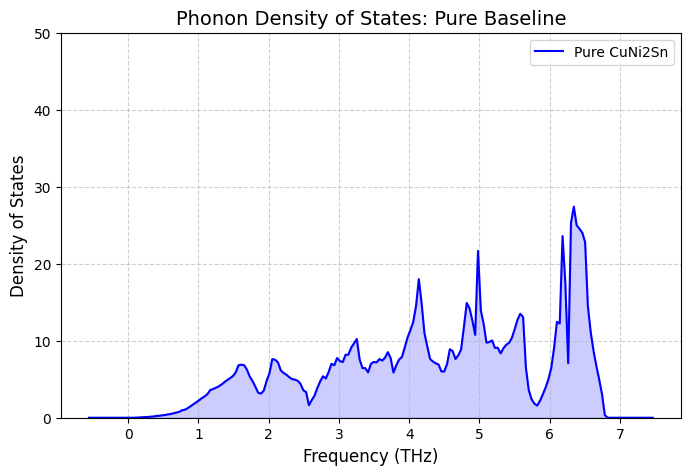

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the pure structure
phonon_calc = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Pure CuNi2Sn...")
pure_phonon_data = phonon_calc.calc(final_structure_pbe)

# 2. Access the Phonopy object
ph = pure_phonon_data["phonon"]

# 3. Trigger the DOS calculation (Fixes the AttributeError)
# We use a mesh of 20x20x20 for resolution
ph.run_mesh([20, 20, 20])
ph.run_total_dos()

# 4. Extract frequencies and densities
# get_total_dos_dict() returns a dictionary with 'frequency-points' and 'total-dos'
dos_dict = ph.get_total_dos_dict()
freqs = dos_dict['frequency_points']
densities = dos_dict['total_dos']

# 5. Visualization for Paper
plt.figure(figsize=(8, 5))
plt.plot(freqs, densities, color='blue', label='Pure CuNi2Sn')
plt.fill_between(freqs, densities, color='blue', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: Pure Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 1. Second 'Doped' version from the pure optimized structure
sac_al_12_5 = final_structure_pbe.copy()

# 2. Replace TWO sites with Aluminum to achieve 12.5% doping (2/16 atoms)
# We use site 12 (Sn) and site 0 (Cu) for a balanced distribution
sac_al_12_5.replace(12, "Al")
sac_al_12_5.replace(0, "Al")

print(f"Created 12.5% Al-doped structure: {sac_al_12_5.formula}")

# 3. Proceed to High-Precision Relaxation
print("Starting high-precision optimization for 12.5% Al...")
relax_results_12_5 = relax_calc.calc(sac_al_12_5)
opt_struct_12_5 = relax_results_12_5["final_structure"]

print(f"12.5% Optimized Energy: {relax_results_12_5['energy']:.4f} eV")

# 4. Calculate Elastic Moduli
elastic_results_12_5 = elastic_calc.calc(opt_struct_12_5)
multiplier_GPa = 160.2176621

bulk_12_5 = elastic_results_12_5['bulk_modulus_vrh'] * multiplier_GPa
shear_12_5 = elastic_results_12_5['shear_modulus_vrh'] * multiplier_GPa

print(f"--- 12.5% Al Doping Results ---")
print(f"Bulk Modulus: {bulk_12_5:.2f} GPa")
print(f"Shear Modulus: {shear_12_5:.2f} GPa")

Created 12.5% Al-doped structure: Al2 Cu3 Ni8 Sn3
Starting high-precision optimization for 12.5% Al...
12.5% Optimized Energy: -77.7094 eV
--- 12.5% Al Doping Results ---
Bulk Modulus: 136.47 GPa
Shear Modulus: 43.35 GPa


Calculating Phonon Data for 12.5% Al-Doped structure...


/usr/local/lib/python3.12/dist-packages/matcalc/_phonon.py:203: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000, -1.00000,  0.00000]
  [ 0.00000, -0.00000, -1.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


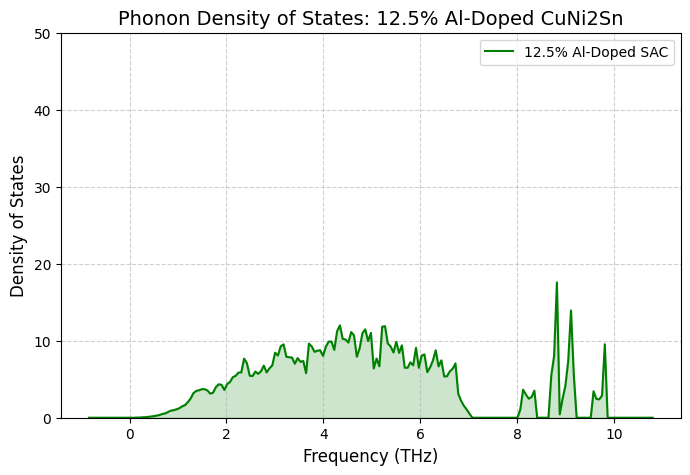

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize Phonon Calculator for 12.5%
# Using the same supercell settings for a fair comparison
phonon_calc_12_5 = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for 12.5% Al-Doped structure...")
phonon_data_12_5 = phonon_calc_12_5.calc(opt_struct_12_5)
ph_12_5 = phonon_data_12_5["phonon"]

# 2. Run high-resolution DOS
ph_12_5.run_mesh([20, 20, 20])
ph_12_5.run_total_dos()

dos_dict_12_5 = ph_12_5.get_total_dos_dict()
freqs_12_5 = dos_dict_12_5['frequency_points']
densities_12_5 = dos_dict_12_5['total_dos']

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.plot(freqs_12_5, densities_12_5, color='green', label='12.5% Al-Doped SAC')
plt.fill_between(freqs_12_5, densities_12_5, color='green', alpha=0.2)

# Set Y-axis range to 0-50 for consistent comparison
plt.ylim(0, 50)

plt.title("Phonon Density of States: 12.5% Al-Doped CuNi2Sn", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# 4. Extract Thermodynamic Stability at Harsh Environment (473K)
ph_12_5.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_12_5 = ph_12_5.get_thermal_properties_dict()

temps_12_5 = tp_12_5['temperatures']
idx_473 = (np.abs(temps_12_5 - 473)).argmin()

print(f"--- 12.5% Al THERMODYNAMICS ---")
print(f"Free Energy at 473K: {tp_12_5['free_energy'][idx_473]:.4f} kJ/mol")
print(f"Entropy at 473K: {tp_12_5['entropy'][idx_473]:.4f} J/K/mol")

--- 12.5% Al THERMODYNAMICS ---
Free Energy at 473K: -154.0050 kJ/mol
Entropy at 473K: 732.6380 J/K/mol
